# PINN Loss Landscape Analysis: `local_landscape_adam150`

This notebook analyzes the Adam-only 150 epoch PINN run in `outputs/pinn/local_landscape_adam150`.

It covers:
- training-loss evolution across epochs
- 1D loss-landscape slices for `init`, `epoch_050pct`, and `best`
- 2D heatmaps for `init` and `best`
- 3D surface plots for the saved 2D landscapes
- compact numerical summaries of center loss, minima, and dynamic range


In [1]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

REPO_ROOT = Path(r'/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems')
RUN_DIR = Path(r'/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/outputs/pinn/local_landscape_adam150')
METRICS_PATH = RUN_DIR / 'metrics.csv'
LANDSCAPE_DIR = RUN_DIR / 'loss_landscape'

CHECKPOINTS_1D = {
    'init': LANDSCAPE_DIR / 'init_1d',
    'epoch_050pct': LANDSCAPE_DIR / 'epoch_050pct_1d',
    'best': LANDSCAPE_DIR / 'best_1d',
}
CHECKPOINTS_2D = {
    'init': LANDSCAPE_DIR / 'init_2d',
    'epoch_050pct': LANDSCAPE_DIR / 'epoch_050pct_2d',
    'best': LANDSCAPE_DIR / 'best_2d',
}

RUN_DIR, LANDSCAPE_DIR


(PosixPath('/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/outputs/pinn/local_landscape_adam150'),
 PosixPath('/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/outputs/pinn/local_landscape_adam150/loss_landscape'))

In [2]:
def load_manifest(path: Path) -> dict:
    return json.loads((path / 'manifest.json').read_text())


def load_landscape(path: Path) -> dict:
    manifest = load_manifest(path)
    coords = np.load(path / 'coordinates.npz')
    losses = {}
    for loss_path in sorted(path.glob('loss_*.npy')):
        losses[loss_path.stem.replace('loss_', '')] = np.load(loss_path)
    return {
        'path': path,
        'manifest': manifest,
        'coords': {k: coords[k] for k in coords.files},
        'losses': losses,
    }


def available_losses(landscape: dict) -> list[str]:
    preferred = ['total', 'data', 'dt', 'physics', 'ic']
    present = list(landscape['losses'].keys())
    ordered = [name for name in preferred if name in present]
    ordered.extend([name for name in present if name not in ordered])
    return ordered


def safe_log10(arr: np.ndarray, eps: float = 1e-16) -> np.ndarray:
    return np.log10(np.maximum(arr, eps))


def summarize_1d_landscape(name: str, landscape: dict) -> pd.DataFrame:
    alpha = landscape['coords']['alpha']
    rows = []
    center_idx = int(np.argmin(np.abs(alpha)))
    for loss_name, values in landscape['losses'].items():
        min_idx = int(np.nanargmin(values))
        rows.append({
            'checkpoint': name,
            'loss': loss_name,
            'center_alpha': float(alpha[center_idx]),
            'center_value': float(values[center_idx]),
            'min_alpha': float(alpha[min_idx]),
            'min_value': float(values[min_idx]),
            'max_value': float(np.nanmax(values)),
            'range': float(np.nanmax(values) - np.nanmin(values)),
        })
    return pd.DataFrame(rows)


def summarize_2d_landscape(name: str, landscape: dict) -> pd.DataFrame:
    alpha = landscape['coords']['alpha']
    beta = landscape['coords']['beta']
    alpha_center = int(np.argmin(np.abs(alpha)))
    beta_center = int(np.argmin(np.abs(beta)))
    rows = []
    for loss_name, values in landscape['losses'].items():
        min_flat = int(np.nanargmin(values))
        min_idx = np.unravel_index(min_flat, values.shape)
        rows.append({
            'checkpoint': name,
            'loss': loss_name,
            'center_alpha': float(alpha[alpha_center]),
            'center_beta': float(beta[beta_center]),
            'center_value': float(values[alpha_center, beta_center]),
            'min_alpha': float(alpha[min_idx[0]]),
            'min_beta': float(beta[min_idx[1]]),
            'min_value': float(values[min_idx]),
            'max_value': float(np.nanmax(values)),
            'range': float(np.nanmax(values) - np.nanmin(values)),
        })
    return pd.DataFrame(rows)


def plot_training_curves(metrics: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    loss_cols = [
        col for col in ['train_total_loss', 'val_data_loss', 'val_physics_loss', 'test_data_loss']
        if col in metrics.columns
    ]
    for col in loss_cols:
        axes[0].plot(metrics['global_epoch'], metrics[col], label=col)
    axes[0].set_title('Top-level training and validation losses')
    axes[0].set_xlabel('Global epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_yscale('log')
    axes[0].legend(loc='best')

    component_cols = [
        col for col in ['train_data_loss', 'train_dt_loss', 'train_physics_loss', 'train_ic_loss']
        if col in metrics.columns
    ]
    for col in component_cols:
        axes[1].plot(metrics['global_epoch'], metrics[col], label=col)
    axes[1].set_title('Training loss components')
    axes[1].set_xlabel('Global epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_yscale('log')
    axes[1].legend(loc='best')

    grad_cols = [
        col for col in ['train_total_grad_norm', 'train_data_grad_norm', 'train_dt_grad_norm', 'train_physics_grad_norm', 'train_ic_grad_norm']
        if col in metrics.columns and metrics[col].notna().any()
    ]
    if grad_cols:
        for col in grad_cols:
            axes[2].plot(metrics['global_epoch'], metrics[col], label=col)
        axes[2].set_yscale('log')
        axes[2].legend(loc='best')
    else:
        axes[2].text(0.5, 0.5, 'No gradient telemetry saved for this run', ha='center', va='center')
    axes[2].set_title('Gradient telemetry')
    axes[2].set_xlabel('Global epoch')
    axes[2].set_ylabel('Gradient norm')

    plt.tight_layout()
    plt.show()


def plot_1d_slices(landscapes: dict[str, dict], loss_names: list[str] | None = None, log_scale: bool = False) -> None:
    sample = next(iter(landscapes.values()))
    if loss_names is None:
        loss_names = available_losses(sample)
    fig, axes = plt.subplots(len(loss_names), 1, figsize=(11, 3.2 * len(loss_names)), sharex=True)
    if len(loss_names) == 1:
        axes = [axes]
    for ax, loss_name in zip(axes, loss_names):
        for checkpoint_name, landscape in landscapes.items():
            alpha = landscape['coords']['alpha']
            values = landscape['losses'][loss_name]
            ax.plot(alpha, values, label=checkpoint_name, linewidth=2)
        ax.set_ylabel(loss_name)
        ax.set_title(f'1D slice: {loss_name}')
        if log_scale:
            ax.set_yscale('log')
        ax.legend(loc='best')
    axes[-1].set_xlabel('alpha')
    plt.tight_layout()
    plt.show()


def plot_2d_heatmaps(landscape: dict, checkpoint_name: str, loss_names: list[str] | None = None, log_scale: bool = True) -> None:
    if loss_names is None:
        loss_names = available_losses(landscape)
    alpha = landscape['coords']['alpha']
    beta = landscape['coords']['beta']
    fig, axes = plt.subplots(1, len(loss_names), figsize=(4.5 * len(loss_names), 4.2), squeeze=False)
    for ax, loss_name in zip(axes[0], loss_names):
        values = landscape['losses'][loss_name]
        display = safe_log10(values) if log_scale else values
        im = ax.imshow(
            display,
            origin='lower',
            aspect='auto',
            extent=[beta.min(), beta.max(), alpha.min(), alpha.max()],
            cmap='viridis',
        )
        ax.set_title(f'{checkpoint_name}: {loss_name}')
        ax.set_xlabel('beta')
        ax.set_ylabel('alpha')
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('log10(loss)' if log_scale else 'loss')
    plt.tight_layout()
    plt.show()


def plot_2d_contours(landscape: dict, checkpoint_name: str, loss_names: list[str] | None = None, log_scale: bool = True, levels: int = 18) -> None:
    if loss_names is None:
        loss_names = available_losses(landscape)
    alpha = landscape['coords']['alpha']
    beta = landscape['coords']['beta']
    B, A = np.meshgrid(beta, alpha)
    fig, axes = plt.subplots(1, len(loss_names), figsize=(4.8 * len(loss_names), 4.4), squeeze=False)
    for ax, loss_name in zip(axes[0], loss_names):
        values = landscape['losses'][loss_name]
        display = safe_log10(values) if log_scale else values
        contour = ax.contourf(B, A, display, levels=levels, cmap='viridis')
        ax.contour(B, A, display, levels=levels, colors='k', linewidths=0.3, alpha=0.35)
        ax.set_title(f'{checkpoint_name}: {loss_name}')
        ax.set_xlabel('beta')
        ax.set_ylabel('alpha')
        cbar = plt.colorbar(contour, ax=ax)
        cbar.set_label('log10(loss)' if log_scale else 'loss')
    plt.tight_layout()
    plt.show()


def plot_3d_surfaces(landscape: dict, checkpoint_name: str, loss_names: list[str] | None = None, log_scale: bool = True) -> None:
    if loss_names is None:
        loss_names = available_losses(landscape)
    alpha = landscape['coords']['alpha']
    beta = landscape['coords']['beta']
    B, A = np.meshgrid(beta, alpha)
    fig = plt.figure(figsize=(5.2 * len(loss_names), 4.8))
    for idx, loss_name in enumerate(loss_names, start=1):
        ax = fig.add_subplot(1, len(loss_names), idx, projection='3d')
        values = landscape['losses'][loss_name]
        display = safe_log10(values) if log_scale else values
        surf = ax.plot_surface(B, A, display, cmap='viridis', linewidth=0, antialiased=True, alpha=0.95)
        ax.set_title(f'{checkpoint_name}: {loss_name}')
        ax.set_xlabel('beta')
        ax.set_ylabel('alpha')
        ax.set_zlabel('log10(loss)' if log_scale else 'loss')
        fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.08)
    plt.tight_layout()
    plt.show()


In [3]:
metrics = pd.read_csv(METRICS_PATH)
landscapes_1d = {name: load_landscape(path) for name, path in CHECKPOINTS_1D.items()}
landscapes_2d = {name: load_landscape(path) for name, path in CHECKPOINTS_2D.items()}

print('Metrics shape:', metrics.shape)
print('1D checkpoints:', list(landscapes_1d.keys()))
print('2D checkpoints:', list(landscapes_2d.keys()))
print('Available 1D losses:', available_losses(next(iter(landscapes_1d.values()))))
print('Available 2D losses:', available_losses(next(iter(landscapes_2d.values()))))


Metrics shape: (150, 18)
1D checkpoints: ['init', 'epoch_050pct', 'best']
2D checkpoints: ['init', 'epoch_050pct', 'best']
Available 1D losses: ['total', 'data', 'dt', 'physics', 'ic']
Available 2D losses: ['total', 'data', 'dt', 'physics', 'ic']


## Training Dynamics

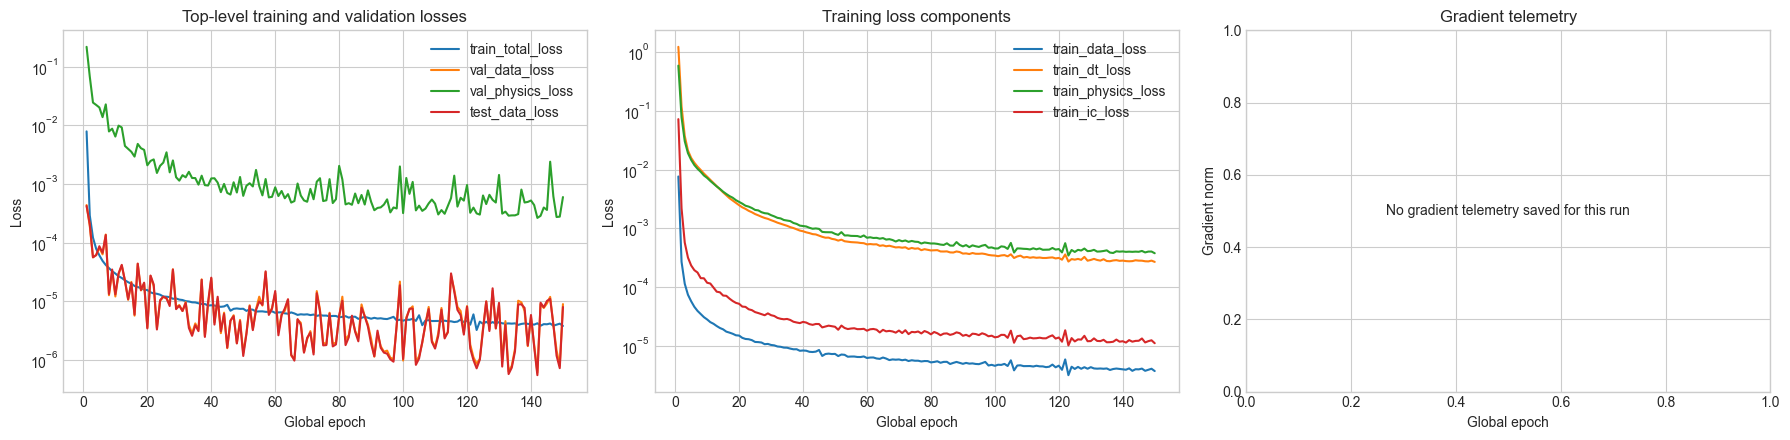

,global_epoch,train_total_loss,val_data_loss,val_physics_loss,test_data_loss
140,141,0.000004,1.771904e-06,0.000436,1.669678e-06
141,142,0.000004,6.062175e-07,0.000264,5.498767e-07
142,143,0.000004,8.948741e-06,0.000286,9.456787e-06
143,144,0.000004,7.689389e-06,0.000396,7.887538e-06
144,145,0.000004,9.200625e-06,0.000360,1.014074e-05
145,146,0.000004,1.188932e-05,0.002393,1.100381e-05
146,147,0.000004,4.008163e-06,0.000614,4.013213e-06
147,148,0.000004,1.454069e-06,0.000273,1.181704e-06
148,149,0.000004,7.964737e-07,0.000277,7.241103e-07
149,150,0.000004,8.946992e-06,0.000597,7.982324e-06


In [4]:
plot_training_curves(metrics)

metrics[['global_epoch', 'train_total_loss', 'val_data_loss', 'val_physics_loss', 'test_data_loss']].tail(10)


## Numerical Summary of Saved Landscapes

In [5]:
summary_1d = pd.concat([summarize_1d_landscape(name, landscape) for name, landscape in landscapes_1d.items()], ignore_index=True)
summary_2d = pd.concat([summarize_2d_landscape(name, landscape) for name, landscape in landscapes_2d.items()], ignore_index=True)

summary_1d.sort_values(['loss', 'checkpoint'])


,checkpoint,loss,center_alpha,center_value,min_alpha,min_value,max_value,range
10,best,data,0.0,5.206499e-07,0.0,5.206499e-07,0.562392,0.562392
5,epoch_050pct,data,0.0,1.778219e-06,0.0,1.778219e-06,0.606788,0.606787
0,init,data,0.0,6.079013e-01,1.0,5.472584e-01,0.880006,0.332748
11,best,dt,0.0,1.341666e-04,0.0,1.341666e-04,3.889201,3.889066
6,epoch_050pct,dt,0.0,2.427886e-04,0.0,2.427886e-04,4.040257,4.040014
1,init,dt,0.0,1.631753e+00,-1.0,1.624797e+00,1.633208,0.008411
12,best,ic,0.0,3.158318e-06,0.0,3.158318e-06,1.145777,1.145774
7,epoch_050pct,ic,0.0,4.677764e-06,0.0,4.677764e-06,1.410737,1.410732
2,init,ic,0.0,5.939598e-01,0.9,5.563642e-01,0.943450,0.387085
13,best,physics,0.0,1.794263e-04,0.0,1.794263e-04,29.651900,29.651721


In [6]:
summary_2d.sort_values(['loss', 'checkpoint'])


,checkpoint,loss,center_alpha,center_beta,center_value,min_alpha,min_beta,min_value,max_value,range
10,best,data,0.0,0.0,5.206499e-07,0.0,0.0,5.206499e-07,1.203946,1.203946
5,epoch_050pct,data,0.0,0.0,1.778219e-06,0.0,0.0,1.778219e-06,1.427576,1.427574
0,init,data,0.0,0.0,6.079013e-01,1.0,-0.8,5.099697e-01,0.925148,0.415178
11,best,dt,0.0,0.0,1.341666e-04,0.0,0.0,1.341666e-04,4.950543,4.950409
6,epoch_050pct,dt,0.0,0.0,2.427886e-04,0.0,0.0,2.427886e-04,4.794023,4.793780
1,init,dt,0.0,0.0,1.631753e+00,-1.0,-0.5,1.615779e+00,1.647763,0.031984
12,best,ic,0.0,0.0,3.158318e-06,0.0,0.0,3.158318e-06,1.769428,1.769425
7,epoch_050pct,ic,0.0,0.0,4.677764e-06,0.0,0.0,4.677764e-06,1.887918,1.887913
2,init,ic,0.0,0.0,5.939598e-01,0.9,-1.0,4.280701e-01,0.999205,0.571135
13,best,physics,0.0,0.0,1.794263e-04,0.0,0.0,1.794263e-04,105.733151,105.732971


## 1D Loss Slices

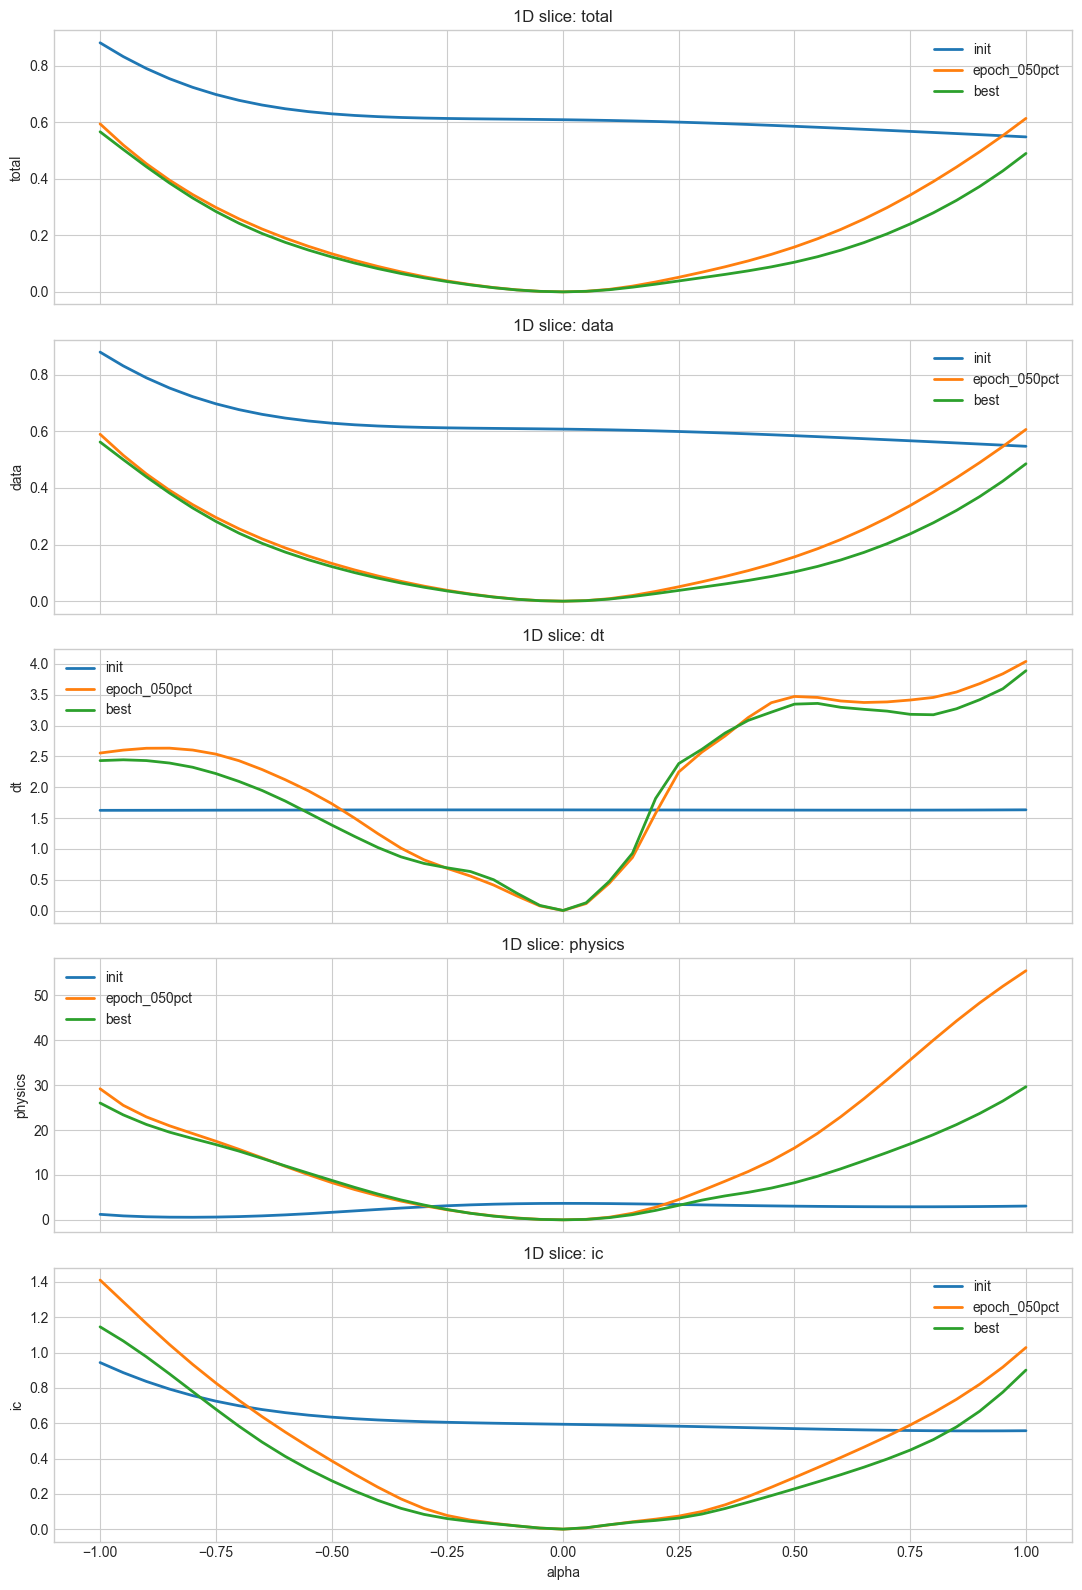

In [7]:
plot_1d_slices(landscapes_1d, log_scale=False)


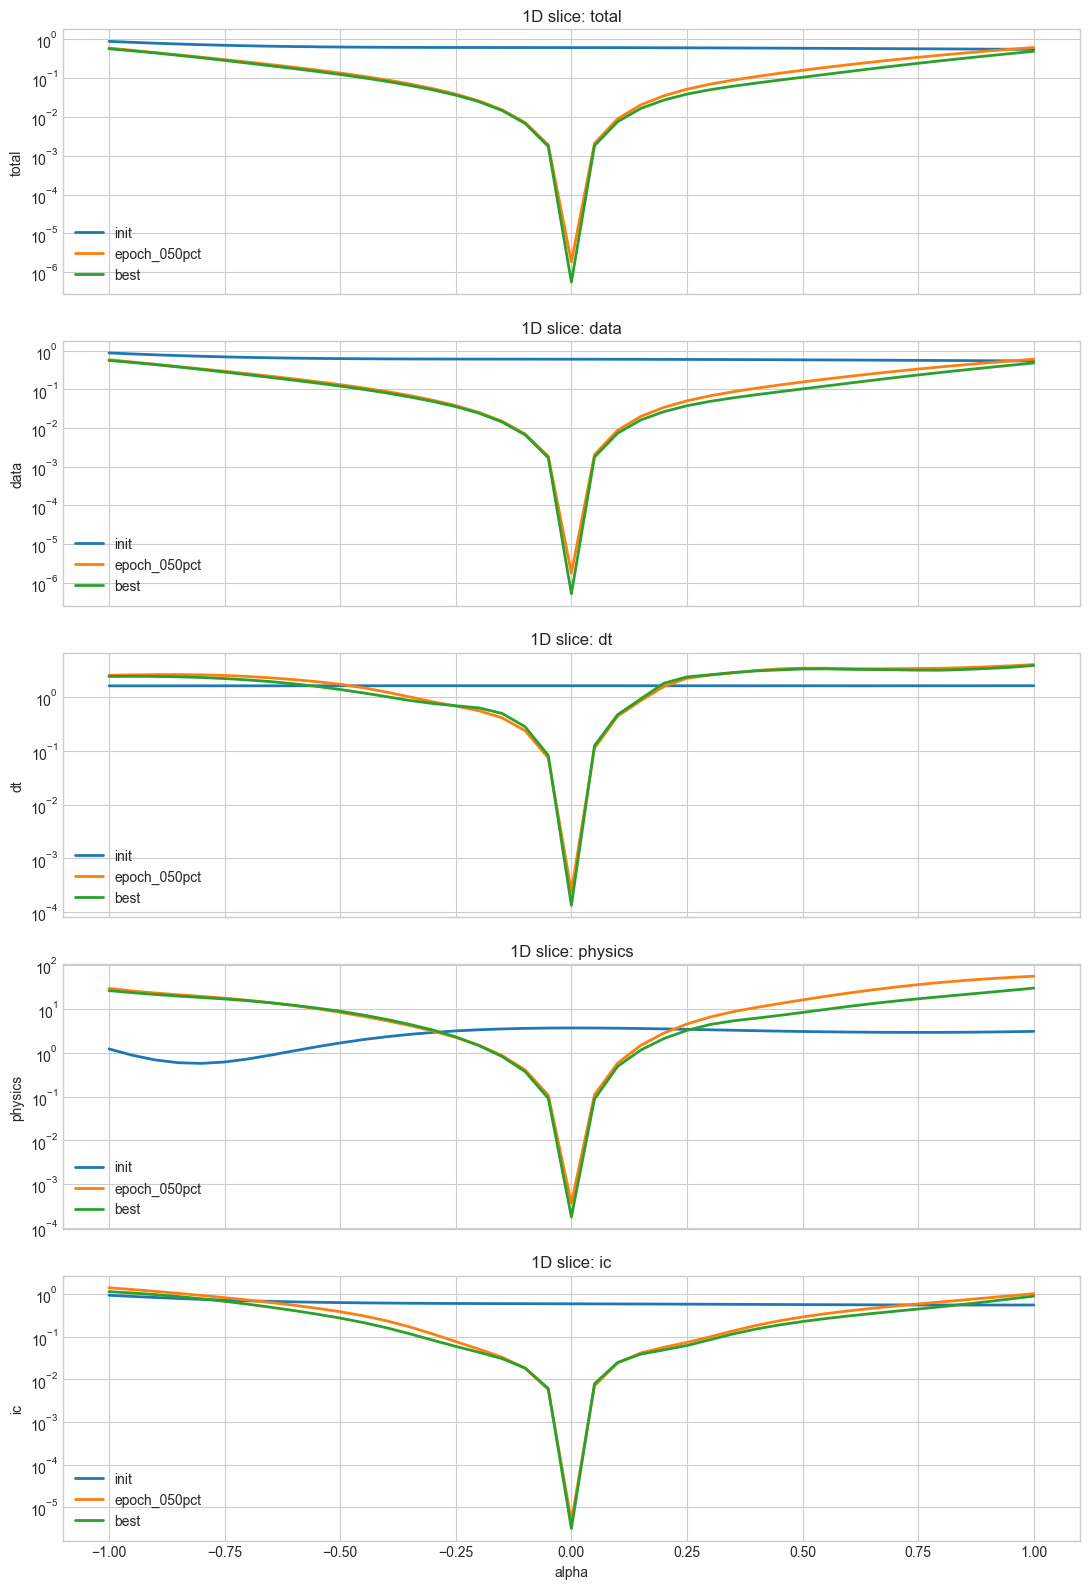

In [8]:
plot_1d_slices(landscapes_1d, log_scale=True)


## 2D Heatmaps

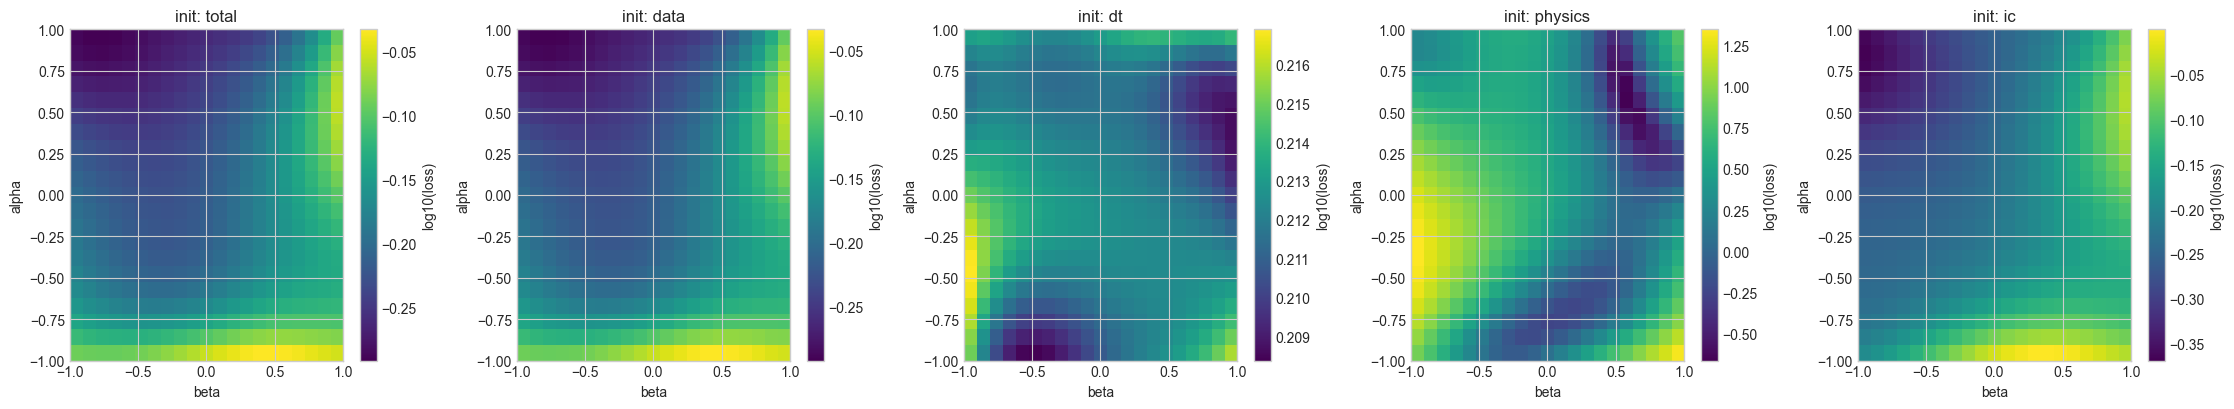

In [9]:
plot_2d_heatmaps(landscapes_2d['init'], 'init', log_scale=True)


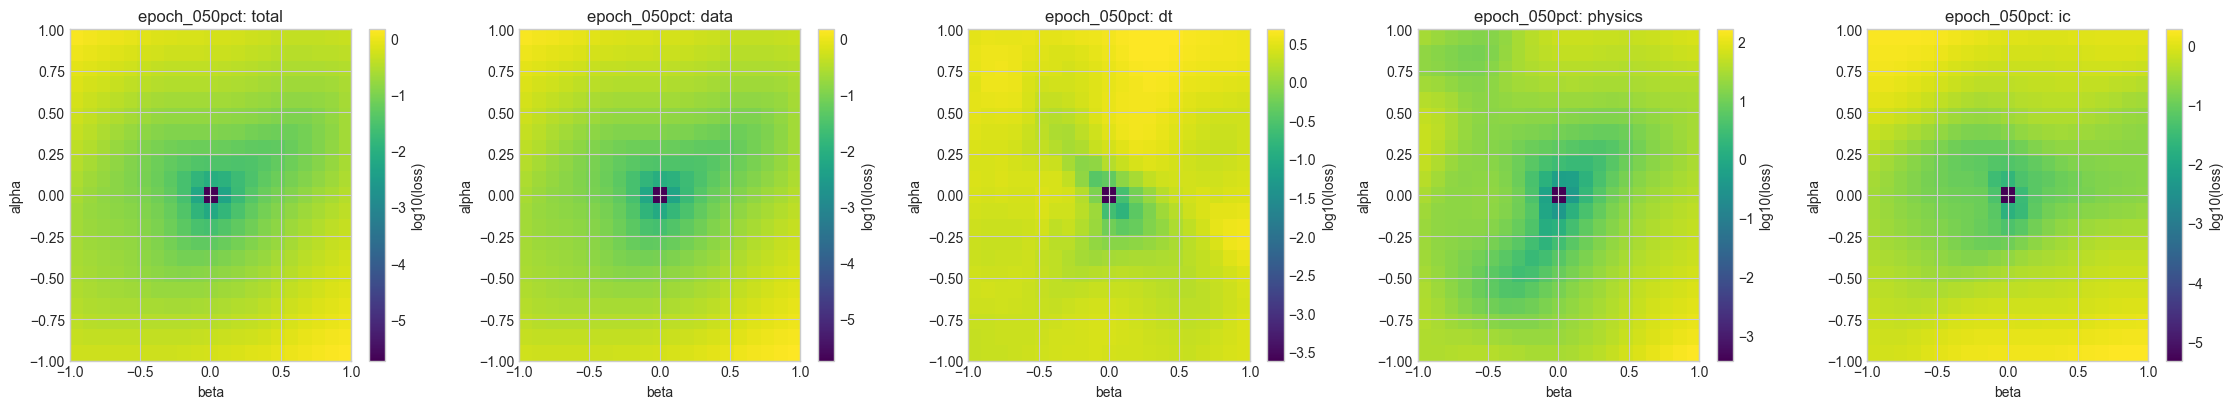

In [10]:
plot_2d_heatmaps(landscapes_2d['epoch_050pct'], 'epoch_050pct', log_scale=True)


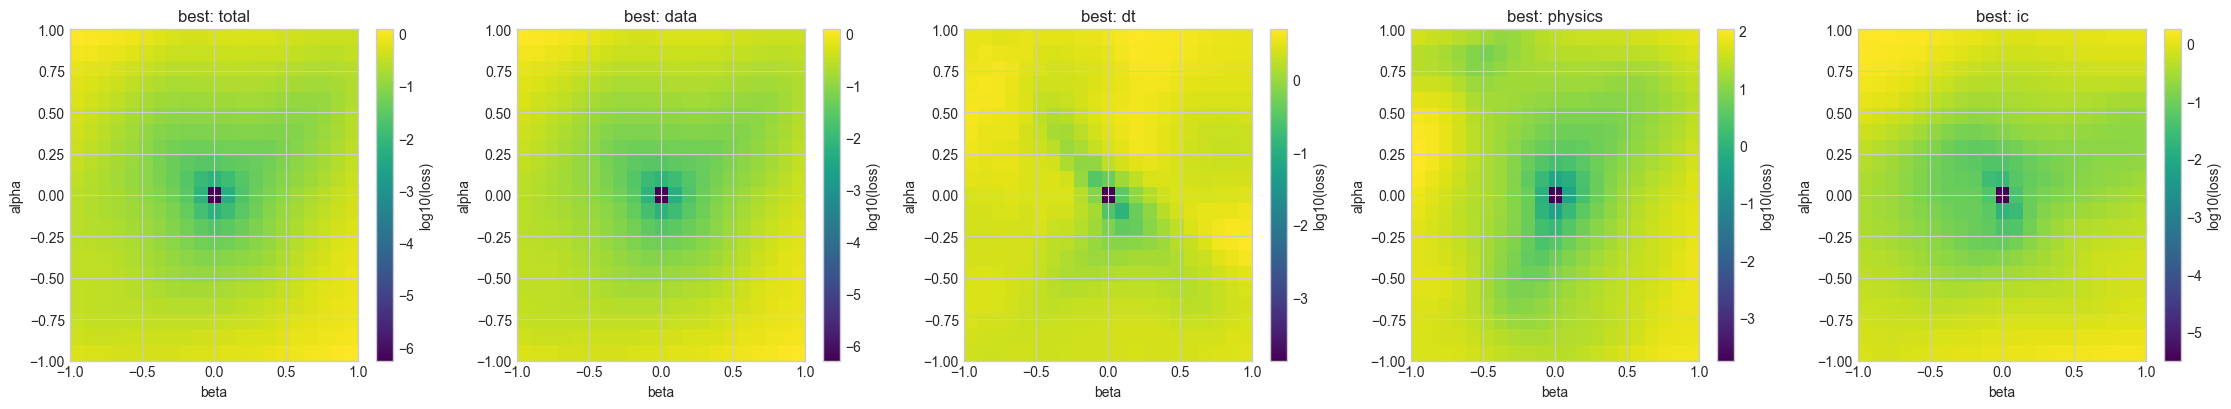

In [11]:
plot_2d_heatmaps(landscapes_2d['best'], 'best', log_scale=True)


## 2D Contour Plots

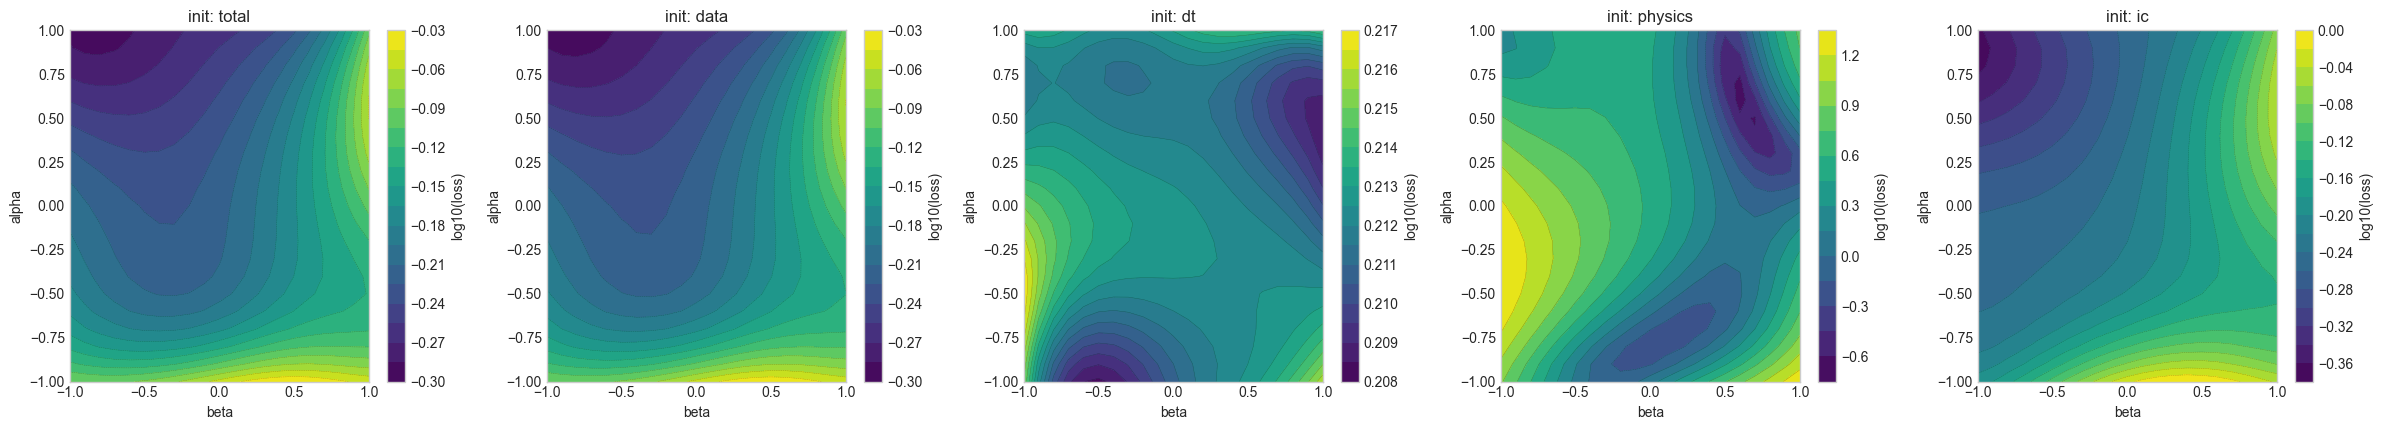

In [12]:
plot_2d_contours(landscapes_2d['init'], 'init', log_scale=True)


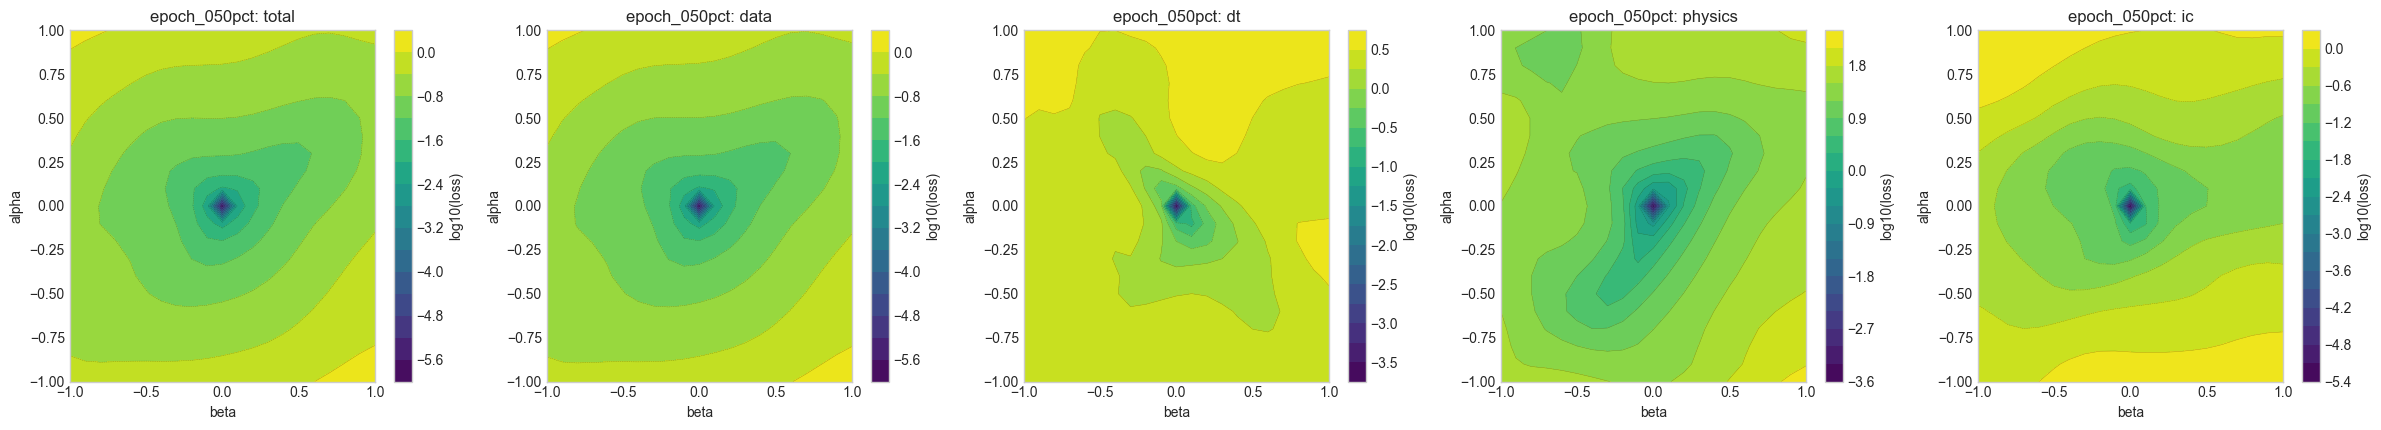

In [13]:
plot_2d_contours(landscapes_2d['epoch_050pct'], 'epoch_050pct', log_scale=True)


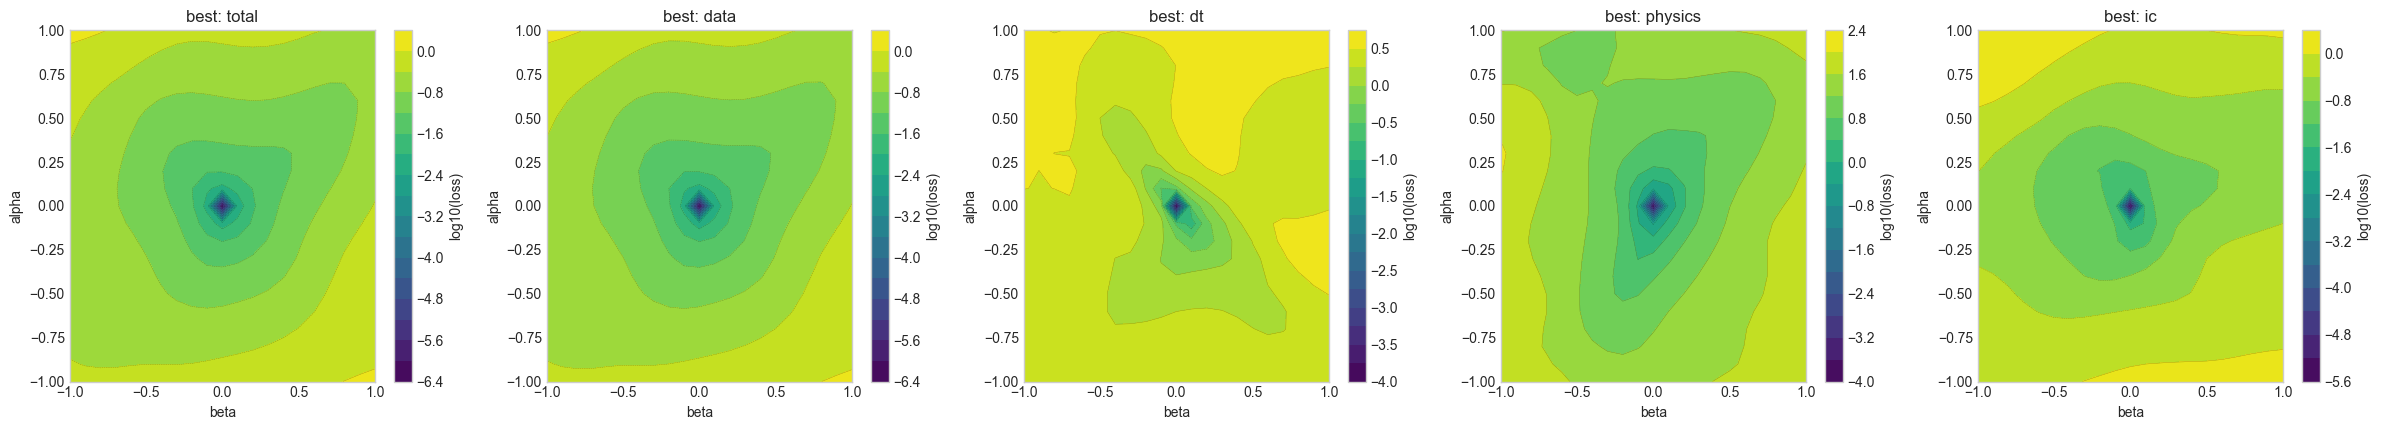

In [14]:
plot_2d_contours(landscapes_2d['best'], 'best', log_scale=True)


## 3D Surface Plots

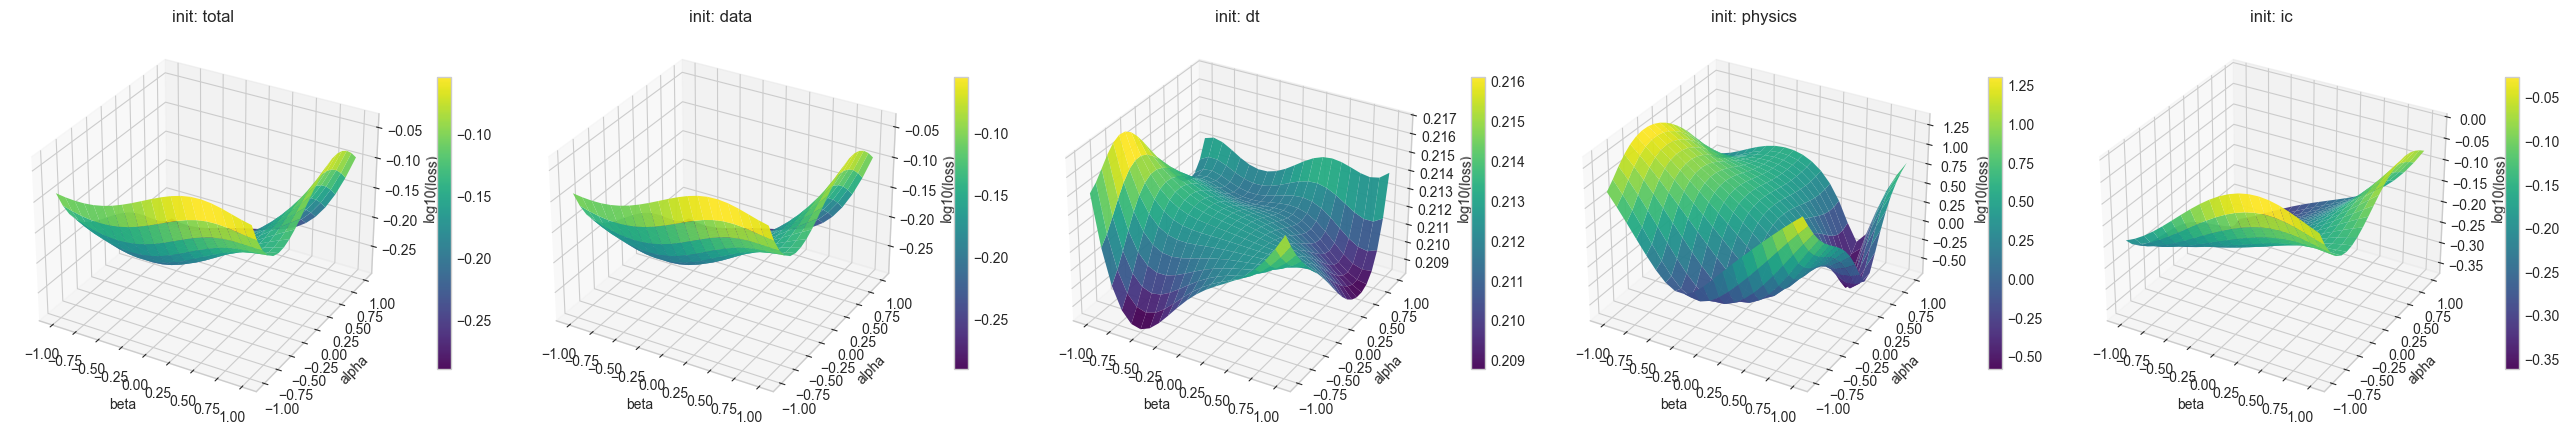

In [15]:
plot_3d_surfaces(landscapes_2d['init'], 'init', log_scale=True)


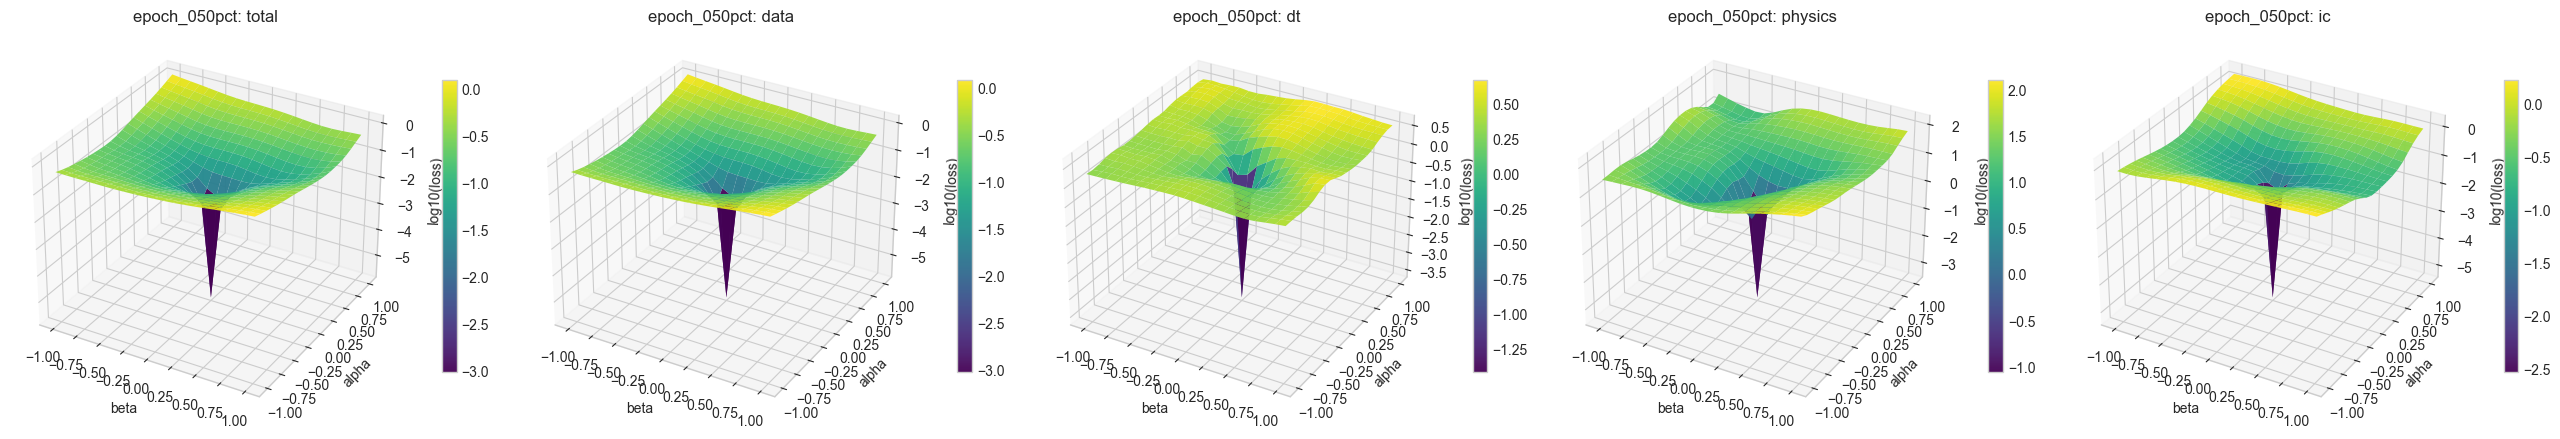

In [16]:
plot_3d_surfaces(landscapes_2d['epoch_050pct'], 'epoch_050pct', log_scale=True)


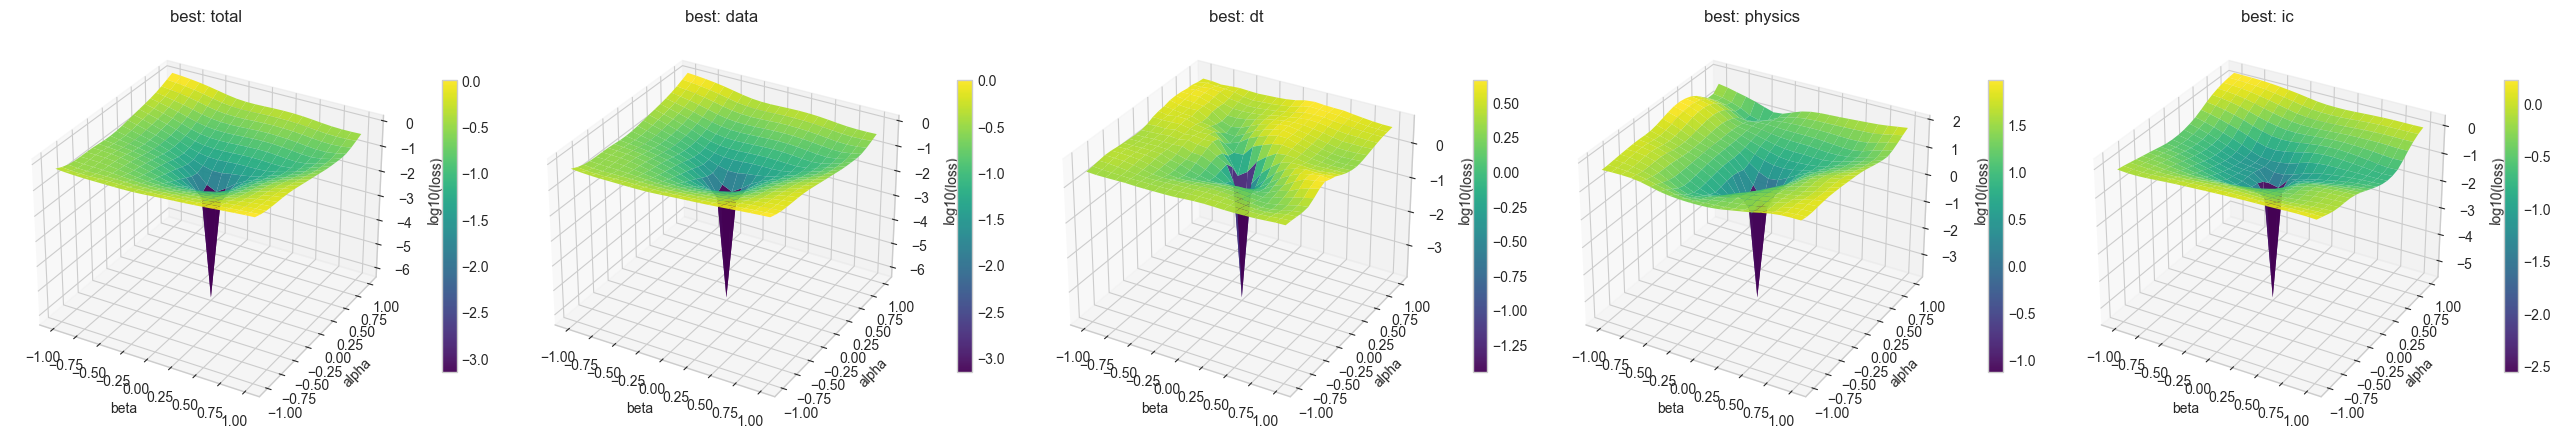

In [17]:
plot_3d_surfaces(landscapes_2d['best'], 'best', log_scale=True)


## Interpretation Notes

In [18]:
total_1d = summary_1d[summary_1d['loss'] == 'total'][['checkpoint', 'center_value', 'min_value', 'range']].sort_values('checkpoint')
total_2d = summary_2d[summary_2d['loss'] == 'total'][['checkpoint', 'center_value', 'min_value', 'range', 'min_alpha', 'min_beta']].sort_values('checkpoint')

print('1D total-loss checkpoints:')
display(total_1d)
print('')
print('2D total-loss checkpoints:')
display(total_2d)

print('Interpretation guide:')
print('- A lower center value at alpha=beta=0 for later checkpoints is expected and indicates training progress.')
print('- A narrower range around the center can indicate a flatter local basin, while a sharp steep bowl suggests higher local sensitivity.')
print('- Comparing component surfaces tells us whether total-loss geometry is dominated by data, dt, physics, or ic constraints.')


1D total-loss checkpoints:


,checkpoint,center_value,min_value,range
14,best,5.551675e-07,5.551675e-07,0.566383
9,epoch_050pct,1.844053e-06,1.844053e-06,0.613769
4,init,6.090249e-01,5.482855e-01,0.332948



2D total-loss checkpoints:


,checkpoint,center_value,min_value,range,min_alpha,min_beta
14,best,5.551675e-07,5.551675e-07,1.210222,0.0,0.0
9,epoch_050pct,1.844053e-06,1.844053e-06,1.445698,0.0,0.0
4,init,6.090249e-01,5.108195e-01,0.416031,1.0,-0.8


Interpretation guide:
- A lower center value at alpha=beta=0 for later checkpoints is expected and indicates training progress.
- A narrower range around the center can indicate a flatter local basin, while a sharp steep bowl suggests higher local sensitivity.
- Comparing component surfaces tells us whether total-loss geometry is dominated by data, dt, physics, or ic constraints.
